,Average Monthly Return,Volatility,Sharpe Ratio
0,0.001003,0.003498,0.286912


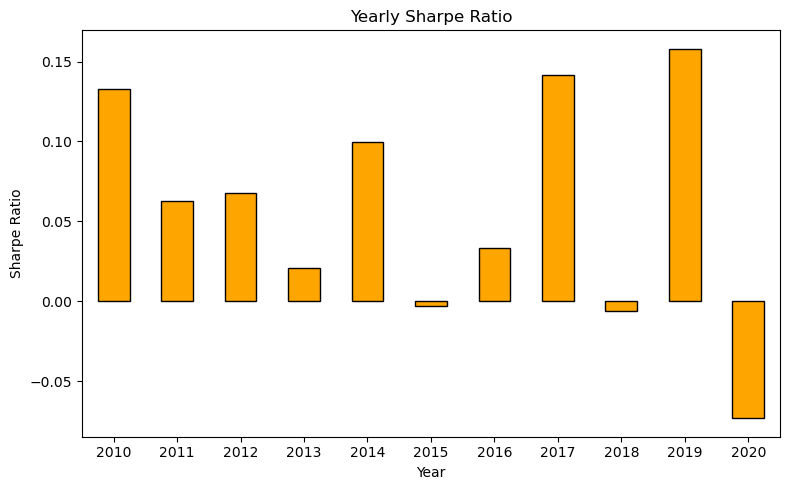

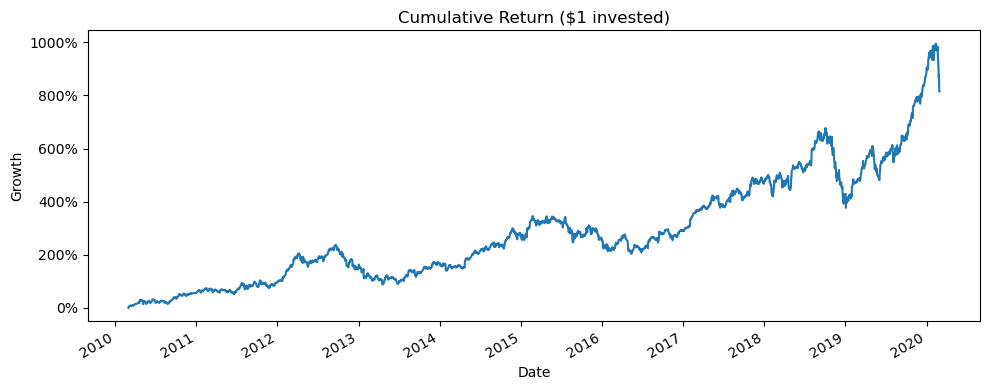

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Load
df = pd.read_csv("downloads/HistoricalQuotes.csv")

# Tidy columns / values we actually use
df.columns = df.columns.str.strip()
df = df.rename(columns={"Close/Last": "Close"})
df["Close"] = (
    df["Close"].astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .astype(float)
)

# Dates → index
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = (df.dropna(subset=["Date"])
        .sort_values("Date")
        .set_index("Date"))

# Daily returns
df["Return"] = df["Close"].pct_change()
df = df.dropna(subset=["Return"])  # drop first NaN

#  Sharpe (monthly) 
# use month-end buckets
monthly_ret = df["Return"].resample("ME").mean()

avg = monthly_ret.mean()
vol = monthly_ret.std()
sharpe = (avg / vol) if vol != 0 else float("nan")

summary = pd.Series(
    {"Average Monthly Return": avg, "Volatility": vol, "Sharpe Ratio": sharpe}
).to_frame().T
display(summary)

# Sharpe by year (bar) 
yr_ret = df["Return"].resample("YE").mean()
yr_vol = df["Return"].resample("YE").std()
yr_sharpe = yr_ret / yr_vol

fig, ax = plt.subplots(figsize=(8, 5))
yr_sharpe.plot(kind="bar", color="orange", edgecolor="black", ax=ax)

ax.set_title("Yearly Sharpe Ratio")
ax.set_ylabel("Sharpe Ratio")
ax.set_xlabel("Year")
ax.set_xticklabels([d.year for d in yr_sharpe.index], rotation=0)

plt.tight_layout()
plt.show()

# shows growth of $1 over time
df["Cumulative"] = (1 + df["Return"]).cumprod() - 1
ax = df["Cumulative"].plot(figsize=(10, 4))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Cumulative Return ($1 invested)")
ax.set_xlabel("Date"); ax.set_ylabel("Growth")
plt.tight_layout(); plt.show()

